# COMP30850 - Assignment
### Shane Whelan
### Student Number: 23344406

## AI Usage
Usage of generative AI tools was kept to a minimum during the completion of this assignment. Any usage is marked with a comment clearly stating why it was used, and what exactly I got from it. Gemini 3 Pro was the model that was being used for any AI assistance.

---

## Task 1: Static Network Construction
- Create an appropriate network representation from the raw data.
- Each node represents a unique station, with name and area attributes.
- Each edge indicates trips from an origin to a different destination, with an appropriate edge weight.## Task 1 - Static Network Construction

In [1]:
# imports

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt


First, I'd like to read in each CSV and display the first few rows to get an idea of how they're formatted, and what data is present

In [2]:
stations = pd.read_csv('stations.csv')
rentals = pd.read_csv('rentals.csv')

In [3]:
stations.head()

,station_id,name,capacity,area
0,ST_0001,Smithfield North,42,Northside
1,ST_0002,Parnell Square North,45,Northside
2,ST_0003,Clonmel Street,40,Southside
3,ST_0004,Avondale Road,40,Northside
4,ST_0005,Mount Street Lower,38,Southside


In [4]:
rentals.head()

,year,month,day,hour,start_station_id,end_station_id
0,2026,1,27,19,ST_0018,ST_0057
1,2026,1,26,16,ST_0028,ST_0041
2,2026,1,31,7,ST_0013,ST_0060
3,2026,1,28,10,ST_0064,ST_0095
4,2026,1,26,12,ST_0020,ST_0042


Now, I'll create a directed graph using NetworkX, where each node represents a station.

In [5]:
G = nx.DiGraph()

for _, row in stations.iterrows():
    G.add_node(
        row['station_id'],
        name=row['name'],
        capacity=row['capacity'],
        area=row['area']
    )

Once the nodes are added, I can iterate through the rentals data to add edges between stations. The weight of each edge will represent the number of trips between those stations. I will skip any trips that start and end at the same station, as these do not represent a flow between different stations.

In [6]:
for _, row in rentals.iterrows():
    origin = row['start_station_id']
    dest = row['end_station_id']

    if origin == dest:
        continue

    if G.has_edge(origin, dest):
        G[origin][dest]['weight'] += 1
    else:
        G.add_edge(origin, dest, weight=1)

### Data Validation
Before proceeding to analysis, I want to perform a quick sanity check to verify that the graph was constructed correctly. I'll confirm that all stations from the CSV are present as nodes, and check whether any station IDs appearing in the rentals data are missing from the stations file.

*Gemini helped me here to ensure I did not miss any important validation steps, and to help me interpret the results of the validation checks.*

In [7]:
# check that every station from the CSV is in the graph
station_ids_csv = set(stations['station_id'])
station_ids_graph = set(G.nodes())

assert station_ids_csv == station_ids_graph, "Mismatch between CSV stations and graph nodes!"
print(f"✓ All {len(station_ids_csv)} stations from stations.csv are present as nodes in the graph.")

# check for any station IDs in rentals that are not in the stations CSV
rental_station_ids = set(rentals['start_station_id']).union(set(rentals['end_station_id']))
missing_from_stations = rental_station_ids - station_ids_csv

if missing_from_stations:
    print(f"Warning: {len(missing_from_stations)} station IDs in rentals.csv are not in stations.csv: {missing_from_stations}")
else:
    print(f"All station IDs in rentals.csv are accounted for in stations.csv.")

# count self-loops that were skipped
self_loops = rentals[rentals['start_station_id'] == rentals['end_station_id']].shape[0]
total_rentals = rentals.shape[0]
print(f"✓ {self_loops} self-loop trips were excluded out of {total_rentals} total rentals ({self_loops/total_rentals*100:.1f}%).")
print(f"✓ Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

✓ All 110 stations from stations.csv are present as nodes in the graph.
All station IDs in rentals.csv are accounted for in stations.csv.
✓ 73 self-loop trips were excluded out of 2198 total rentals (3.3%).
✓ Graph has 110 nodes and 1187 edges.


The validation confirms that the data pipeline is correct: all 110 stations are represented, no unknown station IDs exist in the rentals data, and the graph is ready for analysis.

---

## Task 2: Static Network Characterisation
- Calculate global network measures to understand the overall structure of the bike network.
- Compute centrality measures to identify the most important stations.
- Calculate the net flow for each station to identify areas of high demand or surplus.## Task 2 - Static Network Characterisation

In [8]:
# create a lookup dictionary to map station IDs to their human-readable names
station_names = dict(zip(stations['station_id'], stations['name']))

def sid(station_id):
    """Return a formatted string like 'ST_0095 (Princes Street / O'Connell Street)'."""
    return f"{station_id} ({station_names.get(station_id, 'Unknown')})"

First, I want to get a general sense of the network's overall structure. I'll calculate some basic global characterisation measures on the graph to see how interconnected the bike stations are across Dublin.

In [9]:
print(f'Number of nodes: {G.number_of_nodes()}')
print(f'Number of edges: {G.number_of_edges()}')
print(f'Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}')
print(f"Density of the graph: {nx.density(G):.4f}")

Number of nodes: 110
Number of edges: 1187
Average degree: 21.58
Density of the graph: 0.0990


So the network has 110 stations and 1,187 edges, with an average degree of about 21.6, meaning the typical station connects to roughly 21 others.

The density is pretty low at ~0.099 (about 10%), so only about 1 in 10 of all possible station-to-station routes are actually being used. That makes sense though, since people aren't going to cycle between every possible pair of stations. They have their regular commuting routes and they tend to stick to those.

---

### Degree Centrality
Next, I want to identify the most important stations in the network. To do this, I'll calculate several centrality measures, starting with degree centrality, which indicates how many connections each station has to other stations.

In [10]:
# calculate the degree centrality for every node
deg = nx.degree_centrality(G)

In [11]:
s = pd.Series(deg)
# turn the scores into a DataFrame
df = pd.DataFrame(s, columns=["degree_centrality"])
# display the DataFrame sorted by degree centrality
df.sort_values(by="degree_centrality", ascending=False).head(10)

,degree_centrality
ST_0095,0.733945
ST_0068,0.697248
ST_0066,0.587156
ST_0002,0.550459
ST_0001,0.477064
ST_0102,0.440367
ST_0014,0.330275
ST_0073,0.311927
ST_0053,0.275229
ST_0039,0.266055


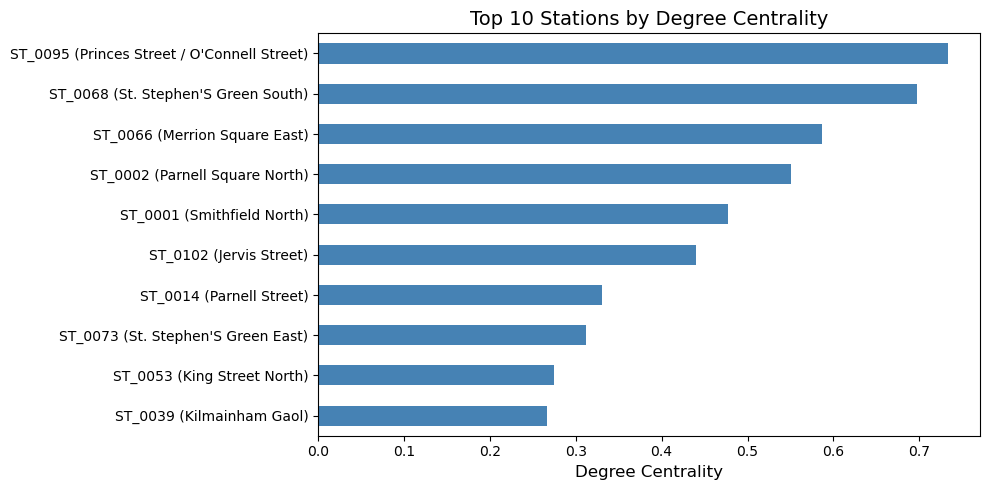

In [12]:
# bar chart of top 10 stations by degree centrality
top_deg = df["degree_centrality"].sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_deg.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_yticklabels([sid(s) for s in top_deg.sort_values().index], fontsize=10)
ax.set_xlabel("Degree Centrality", fontsize=12)
ax.set_title("Top 10 Stations by Degree Centrality", fontsize=14)
plt.tight_layout()
plt.show()



ST_0095 (Princes Street / O'Connell Street) stands out as the most connected station by far, with a degree centrality of ~0.734, meaning it's directly linked to over 73% of all other stations. ST_0068 (St. Stephen's Green South) is close behind. Both of these are major city centre locations so it makes sense that lots of different routes pass through them.

---

### Betweenness Centrality
Betweenness centrality is another important measure that identifies stations that serve as critical bridges or connectors within the network. A station with high betweenness centrality is one that lies on many of the shortest paths between other stations, making it a key point for the flow of bike traffic across the city.

In [13]:
bet = nx.betweenness_centrality(G)

In [14]:
# add this as a column
df["betweenness"] = pd.Series(bet)
df.sort_values(by="betweenness", ascending=False).head(10)

,degree_centrality,betweenness
ST_0066,0.587156,0.285891
ST_0039,0.266055,0.133990
ST_0068,0.697248,0.104559
ST_0095,0.733945,0.096488
ST_0013,0.137615,0.053196
ST_0103,0.119266,0.049143
ST_0042,0.100917,0.037437
ST_0028,0.146789,0.037339
ST_0018,0.220183,0.030484
ST_0033,0.220183,0.025947


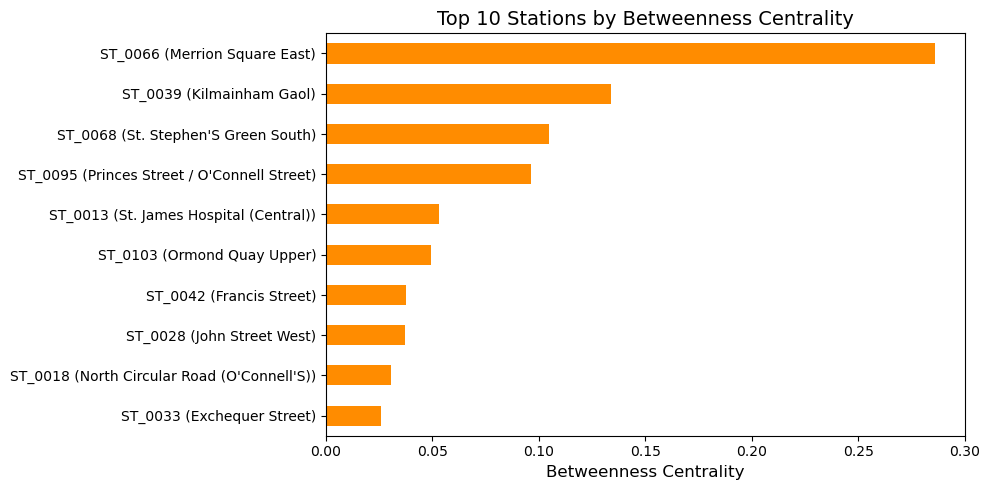

In [15]:
# bar chart of top 10 stations by betweenness centrality
top_bet = df["betweenness"].sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_bet.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_yticklabels([sid(s) for s in top_bet.sort_values().index], fontsize=10)
ax.set_xlabel("Betweenness Centrality", fontsize=12)
ax.set_title("Top 10 Stations by Betweenness Centrality", fontsize=14)
plt.tight_layout()
plt.show()

What's interesting here is that ST_0095 (Princes Street / O'Connell Street), which had the most connections overall, isn't actually the most important bridge. ST_0066 (Merrion Square East) takes the top spot for betweenness with 0.285, which is way ahead of everything else. So Merrion Square East seems to be a key link between different parts of the network.

ST_0039 (Kilmainham Gaol) is also worth noting. It's second in betweenness (0.133) but only has a degree centrality of 0.266, so it doesn't have that many connections. This tells me it's acting as a bridge between clusters that would otherwise be quite separate. If that station went down, people would probably have to take much longer routes to get across the city.

---

### Closeness Centrality
This metric measures the average shortest path from one station to all other stations in the network. In the context of our bike system, a high closeness score means a station is only a short number of "hops" or trips away from anywhere else in the city.

In [16]:
close = nx.closeness_centrality(G)

In [17]:
# add this as a column
df["closeness"] = pd.Series(close)
df.sort_values(by="closeness", ascending=False).head(10)

,degree_centrality,betweenness,closeness
ST_0095,0.733945,0.096488,0.703226
ST_0068,0.697248,0.104559,0.578352
ST_0001,0.477064,0.020906,0.567708
ST_0002,0.550459,0.021792,0.547739
ST_0102,0.440367,0.009552,0.506977
ST_0066,0.587156,0.285891,0.506698
ST_0053,0.275229,0.013662,0.502304
ST_0014,0.330275,0.006171,0.469828
ST_0090,0.247706,0.003666,0.450413
ST_0081,0.201835,0.003754,0.450413


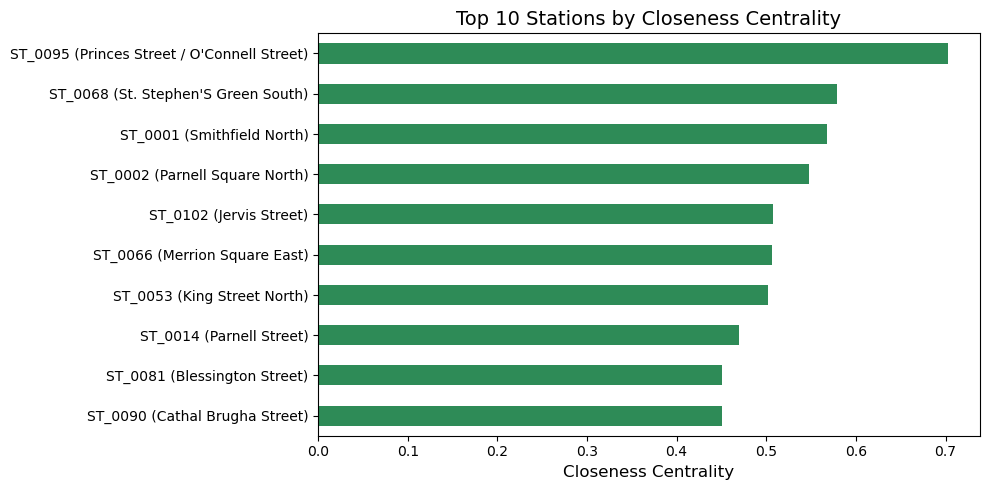

In [18]:
# bar chart of top 10 stations by closeness centrality
top_close = df["closeness"].sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_close.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_yticklabels([sid(s) for s in top_close.sort_values().index], fontsize=10)
ax.set_xlabel("Closeness Centrality", fontsize=12)
ax.set_title("Top 10 Stations by Closeness Centrality", fontsize=14)
plt.tight_layout()
plt.show()

No surprises here, ST_0095 (Princes Street / O'Connell Street) is on top again with a closeness of 0.703. Since it already had the most connections, it makes sense that it also has the shortest average distance to everywhere else.

The top stations on this list (ST_0095, ST_0068, ST_0001, ST_0002) are basically the core of the whole system. If you start at one of these, you can get to almost anywhere else in the network in just one or two hops.

---

### Eigenvector Centrality

While degree centrality simply counts the number of connections a station has, eigenvector centrality measures the quality or influence of those connections. In the context of our bike network, a station scores highly if it is connected to other highly active, popular hubs.

In [19]:
eig = nx.eigenvector_centrality(G, max_iter=1000)

In [20]:
# add this as a column
df["eigenvector"] = pd.Series(eig)
df.sort_values(by="eigenvector", ascending=False).head(10)

,degree_centrality,betweenness,closeness,eigenvector
ST_0095,0.733945,0.096488,0.703226,0.372944
ST_0002,0.550459,0.021792,0.547739,0.344888
ST_0001,0.477064,0.020906,0.567708,0.319767
ST_0102,0.440367,0.009552,0.506977,0.309219
ST_0081,0.201835,0.003754,0.450413,0.244548
ST_0014,0.330275,0.006171,0.469828,0.234409
ST_0053,0.275229,0.013662,0.502304,0.217446
ST_0040,0.229358,0.004639,0.443089,0.198930
ST_0083,0.183486,0.002749,0.446721,0.198095
ST_0090,0.247706,0.003666,0.450413,0.194901


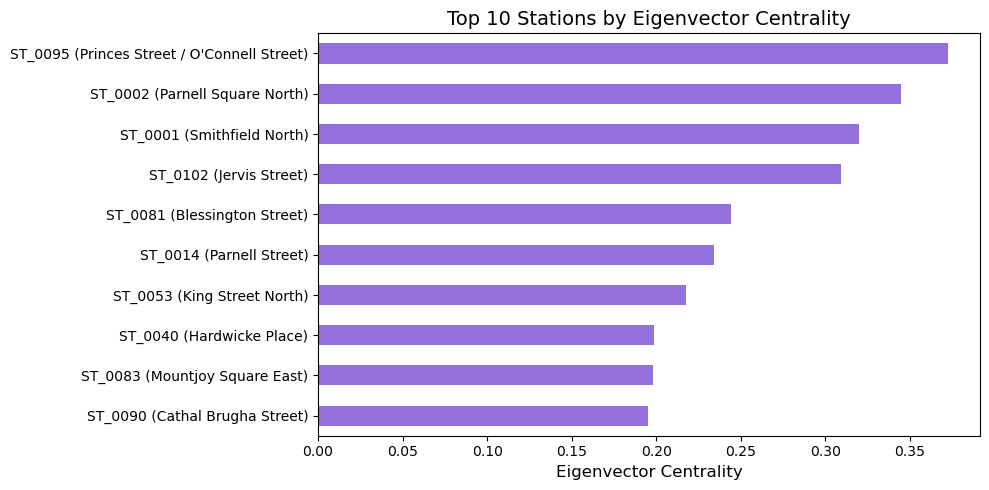

In [21]:
# bar chart of top 10 stations by eigenvector centrality
top_eig = df["eigenvector"].sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_eig.sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_yticklabels([sid(s) for s in top_eig.sort_values().index], fontsize=10)
ax.set_xlabel("Eigenvector Centrality", fontsize=12)
ax.set_title("Top 10 Stations by Eigenvector Centrality", fontsize=14)
plt.tight_layout()
plt.show()

Looking at the results, ST_0095 (Princes Street / O'Connell Street) remains at the top with a score of roughly 0.373. This confirms that it is not only heavily connected, but it is specifically connected to the other most important stations in Dublin. We also see ST_0002 (Parnell Square North) and ST_0001 (Smithfield North) scoring very highly here, even though they had lower betweenness scores earlier.

These top stations form the dense core of the bike system. They are probably located in the very centre of the city, serving as the main arteries where the busiest commuting routes overlap and feed directly into one another.

*Gemini was used to help interpret the Eigenvector Centrality scores in this section*

---

### PageRank
PageRank is a variant of eigenvector centrality that also takes into account the direction of edges and the weight of those edges. In our bike network, a station will have a high PageRank score if it receives a lot of incoming trips from other important stations. This can help identify stations that are not only well-connected but also serve as major destinations for riders coming from other key hubs. While PageRank was originally designed by Google to rank web pages, it is actually highly relevant and insightful for physical transport networks.

In [22]:
pr = nx.pagerank(G)

In [23]:
# add this as a column
df["pagerank"] = pd.Series(pr)
df.sort_values(by="pagerank", ascending=False).head(10)

,degree_centrality,betweenness,closeness,eigenvector,pagerank
ST_0095,0.733945,0.096488,0.703226,0.372944,0.105475
ST_0068,0.697248,0.104559,0.578352,0.000167,0.072213
ST_0002,0.550459,0.021792,0.547739,0.344888,0.068304
ST_0001,0.477064,0.020906,0.567708,0.319767,0.042648
ST_0066,0.587156,0.285891,0.506698,0.000091,0.033155
ST_0102,0.440367,0.009552,0.506977,0.309219,0.030909
ST_0073,0.311927,0.009605,0.381713,0.000094,0.020705
ST_0014,0.330275,0.006171,0.469828,0.234409,0.020038
ST_0081,0.201835,0.003754,0.450413,0.244548,0.016857
ST_0083,0.183486,0.002749,0.446721,0.198095,0.014562


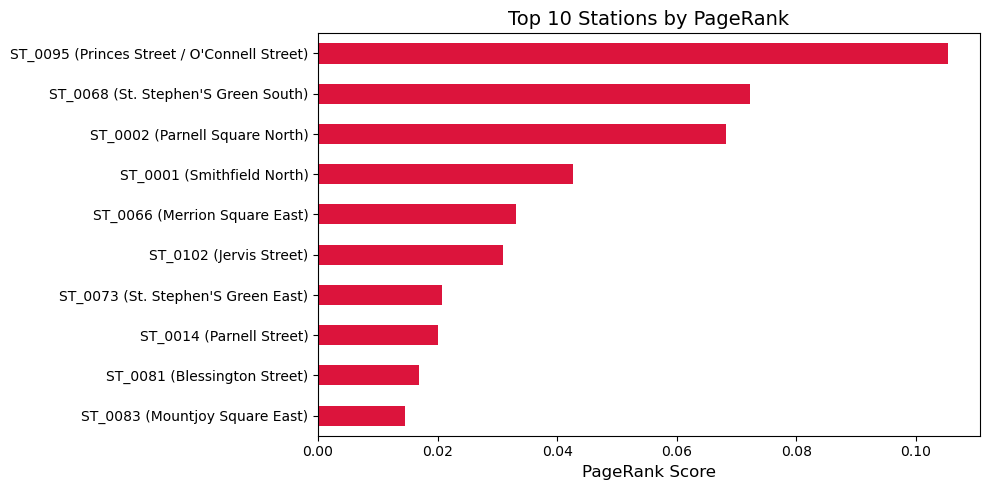

In [24]:
# bar chart of top 10 stations by PageRank
top_pr = df["pagerank"].sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_pr.sort_values().plot(kind='barh', ax=ax, color='crimson')
ax.set_yticklabels([sid(s) for s in top_pr.sort_values().index], fontsize=10)
ax.set_xlabel("PageRank Score", fontsize=12)
ax.set_title("Top 10 Stations by PageRank", fontsize=14)
plt.tight_layout()
plt.show()

PageRank takes into account both direction and weight, so a station scores well if lots of trips come into it from other busy stations. ST_0095 and ST_0068 are on top again here, which basically confirms what we've been seeing across all these metrics. They're not just well-connected, they're where people are actually going to from other major hubs.

---

### Net flows
Finally, for Task 2, I need to calculate the net flow of bikes at each station to identify areas of high demand or surplus. I will do this by taking the weighted in-degree (total bikes arriving) and subtracting the weighted out-degree (total bikes leaving). This will highlight which stations are gaining bikes and which stations are constantly losing them.

In [25]:
# calculate flows
in_flow = dict(G.in_degree(weight='weight'))
out_flow = dict(G.out_degree(weight='weight'))

# add to df
df['in_flow'] = df.index.map(in_flow)
df['out_flow'] = df.index.map(out_flow)
df['net_flow'] = df['in_flow'] - df['out_flow']

In [26]:
# identify significant POSITIVE flow
print("STATIONS GAINING BIKES (Net Arrivals)")
df[['net_flow']].sort_values(by='net_flow', ascending=False).head(5)

STATIONS GAINING BIKES (Net Arrivals)


,net_flow
ST_0095,227
ST_0068,168
ST_0066,97
ST_0002,97
ST_0001,76


In [27]:
# identify significant NEGATIVE flow
print("STATIONS LOSING BIKES (Net Departures)")
df[['net_flow']].sort_values(by='net_flow', ascending=True).head(5)

STATIONS LOSING BIKES (Net Departures)


,net_flow
ST_0009,-24
ST_0110,-19
ST_0046,-19
ST_0088,-19
ST_0012,-19


Looking at the net flow results, the daily imbalances in the
bike network become very clear.

For the stations gaining bikes, ST_0095 (Princes Street / O'Connell Street) and ST_0068 (St. Stephen's Green South) stand out massively with positive net flows of 227 and 168 respectively. Since we already know these are the most central hubs in the network, this tells me they act as primary destinations. Riders flock to these stations, leaving a huge surplus of bikes.

On the flip side, stations like ST_0009 (York Street East) and ST_0110 (Blackhall Place) have a significant negative net flow. These stations are consistently losing bikes faster than they receive them. They likely serve as starting points for commuters, perhaps in more residential areas.

---

## Task 3: Static Network Visualisation
- Extract a subgraph from the bike-trip network created in Task 1 containing only the stations located in the ‘Northside’ area of Dublin. Export this subgraph as a GEXF file.
- Load the GEXF file in Gephi. Use Gephi's layout functionality to create several useful visualisations of the subgraph. Your visualisations should highlight different aspects such as the network's overall connectivity structure. Export the final visualisations as PNG files.

In [28]:
# identify all nodes (stations) in the northside
northside_nodes = []

for n, attrs in G.nodes(data=True):
    if attrs.get('area') == 'Northside':
        northside_nodes.append(n)

print(f"Found {len(northside_nodes)} stations in the Northside.")

Found 43 stations in the Northside.


In [29]:
#  create the subgraph
northside_G = G.subgraph(northside_nodes)

print(f"Subgraph Stats: {northside_G.number_of_nodes()} nodes, {northside_G.number_of_edges()} edges.")

Subgraph Stats: 43 nodes, 429 edges.


In [30]:
# export to GEXF
nx.write_gexf(northside_G, "northside_bikes.gexf")

---

### Visualisation Interpretation
Here is a breakdown of what each visualisation reveals about the Northside bike network:

*Gemini was used in the following markdown cell to help format the interpretation of the visualisations, and to help identify key insights from the different centrality measures used in the visualisations.*

### 1. Community and Influence Map
*(Node Size: Eigenvector Centrality, Colour: Modularity)*

<p align="center">
  <img src="network1.png" width="700">
</p>

All three visualisations use the **Force Atlas** layout algorithm in Gephi (with Repulsion strength = 3000, Attraction strength = 3.0, and "Adjust by Sizes" enabled).

This first map highlights the most influential stations and how they group together. The colours represent different communities detected by the Modularity algorithm. We can clearly see three distinct travel zones: a purple cluster around the main O'Connell Street area, an orange cluster stretching towards Smithfield, and a green cluster in the eastern Docklands area. The node sizes represent Eigenvector Centrality. Stations like Princes Street / O'Connell Street and Parnell Square North are massive, showing they are not just busy, but they are directly connected to other highly active hubs.

---

### 2. Network Bottlenecks Map
*(Node Size: Betweenness Centrality, Colour: Modularity)*

<p align="center">
  <img src="network2.png" width="700">
</p>

In this second map, I changed the node sizes to reflect Betweenness Centrality, while keeping the same Force Atlas layout and Modularity colouring for consistency. This highlights the "bridge" stations. While Princes Street remains very large, other stations change in relative importance. For example, stations bordering the different coloured clusters stand out more because they act as the physical transit bridges between the distinct neighbourhoods. If these specific bottleneck stations were removed or ran out of bikes, navigating between the green Docklands area and the rest of the Northside would become incredibly inefficient.

---

### 3. The Commuter Backbone Map
*(Filtered by Edge Weight)*

<p align="center">
  <img src="network3.png" width="700">
</p>

For the final visualisation, I used the same Force Atlas layout but applied a filter to hide all the low-weight edges. In a raw network graph, random one-off trips can create visual noise. By filtering out these weak connections, the underlying "commuter backbone" of the Northside is revealed. The remaining thick lines show the primary, high-volume traffic corridors. It is very clear that the vast majority of heavy, consistent traffic is funneling directly into those central hubs like Princes Street and Smithfield North.

---

## Task 4: Dynamic Network Analysis

### 4a. Constructing Daily Time Networks
Up until now, I have analysed the Dublin bike system as a single, static entity. However, transport networks are highly dynamic.



To see how things change over time, I'll split the data into daily chunks. By grouping the trip data by date, I can build a separate directed graph for each day, and then compare how the network's structure and connectivity look on different days of the week.

In [31]:
# combine year, month, and day into a single date column
rentals['date'] = pd.to_datetime(rentals[['year', 'month', 'day']]).dt.date

In [32]:
# create a dictionary to hold our daily graphs
daily_graphs = {}

# group the dataframe by the new date column
for current_date, daily_data in rentals.groupby('date'):

    # create a new directed graph for this specific day
    G_day = nx.DiGraph()

    # count the trips between stations for this day to get edge weights
    # filter out self-loops for consistency with the static graph in Task 1
    daily_filtered = daily_data[daily_data['start_station_id'] != daily_data['end_station_id']]
    trip_counts = daily_filtered.groupby(['start_station_id', 'end_station_id']).size().reset_index(name='weight')

    # add the weighted edges to the daily graph
    for _, row in trip_counts.iterrows():
        G_day.add_edge(row['start_station_id'],
                       row['end_station_id'],
                       weight=row['weight'])

    # store the finished graph in our dictionary
    daily_graphs[current_date] = G_day

In [33]:
# look at the first day's stats to confirm correct processing
first_day = list(daily_graphs.keys())[0]
first_G = daily_graphs[first_day]
print(f"Stats for {first_day}: {first_G.number_of_nodes()} nodes, {first_G.number_of_edges()} edges")

Stats for 2026-01-26: 108 nodes, 284 edges


Now that I have a separate graph for each day, I can calculate the same global metrics (nodes, edges, density) for each daily graph. This will allow me to track how the network's structure evolves over time and identify any patterns or trends in rider behaviour across different days of the week.

In [34]:
# list to store our daily metrics
rows = []

# calculate metrics for each day
for date, G_day in daily_graphs.items():

    nodes = G_day.number_of_nodes()
    edges = G_day.number_of_edges()
    density = nx.density(G_day)
    avg_clustering = nx.average_clustering(G_day)
    num_scc = nx.number_strongly_connected_components(G_day)

    # average shortest path length over the largest strongly connected component
    largest_scc = max(nx.strongly_connected_components(G_day), key=len)
    scc_sub = G_day.subgraph(largest_scc)
    avg_path_len = nx.average_shortest_path_length(scc_sub)

    # store the results just like the lab notebook
    rows.append({
        "Date": date,
        "Nodes": nodes,
        "Edges": edges,
        "Density": density,
        "Avg Clustering": avg_clustering,
        "Num SCCs": num_scc,
        "Avg Path Length (Largest SCC)": avg_path_len
    })

In [35]:
# convert to dataframe and set the date as the index
df_metrics = pd.DataFrame(rows).set_index("Date")
df_metrics = df_metrics.sort_index()

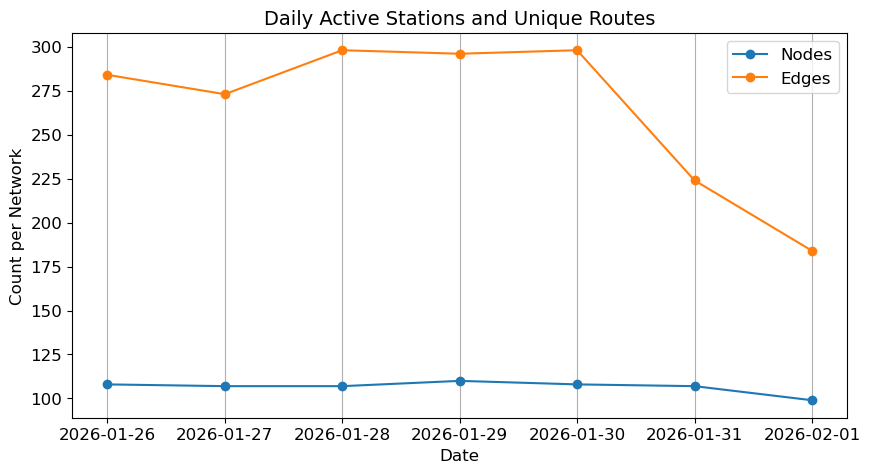

In [36]:
# plot nodes and edges
ax1 = df_metrics[["Nodes", "Edges"]].plot(figsize=(10, 5), style=".-", ms=12, fontsize=12, zorder=3)
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Count per Network", fontsize=12)
ax1.set_title("Daily Active Stations and Unique Routes", fontsize=14)
ax1.xaxis.grid()
ax1.legend(fontsize=12)
plt.show()

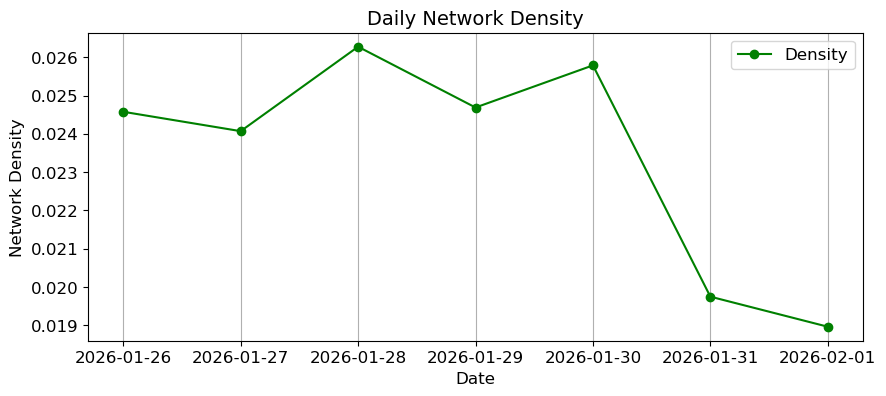

In [37]:
# plot density on a separate graph so the scales don't mess up
ax2 = df_metrics[["Density"]].plot(figsize=(10, 4), style=".-", ms=12, fontsize=12, zorder=3, color="green")
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Network Density", fontsize=12)
ax2.set_title("Daily Network Density", fontsize=14)
ax2.xaxis.grid()
ax2.legend(fontsize=12)
plt.show()

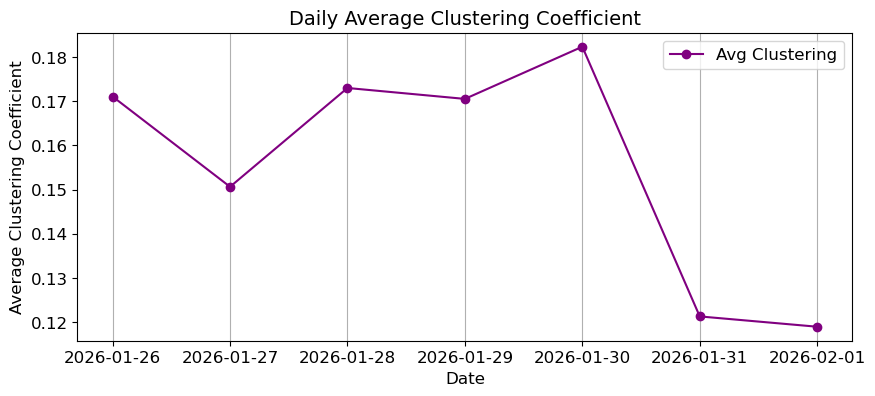

In [38]:
# plot average clustering coefficient
ax3 = df_metrics[["Avg Clustering"]].plot(figsize=(10, 4), style=".-", ms=12, fontsize=12, zorder=3, color="purple")
ax3.set_xlabel("Date", fontsize=12)
ax3.set_ylabel("Average Clustering Coefficient", fontsize=12)
ax3.set_title("Daily Average Clustering Coefficient", fontsize=14)
ax3.xaxis.grid()
ax3.legend(fontsize=12)
plt.show()

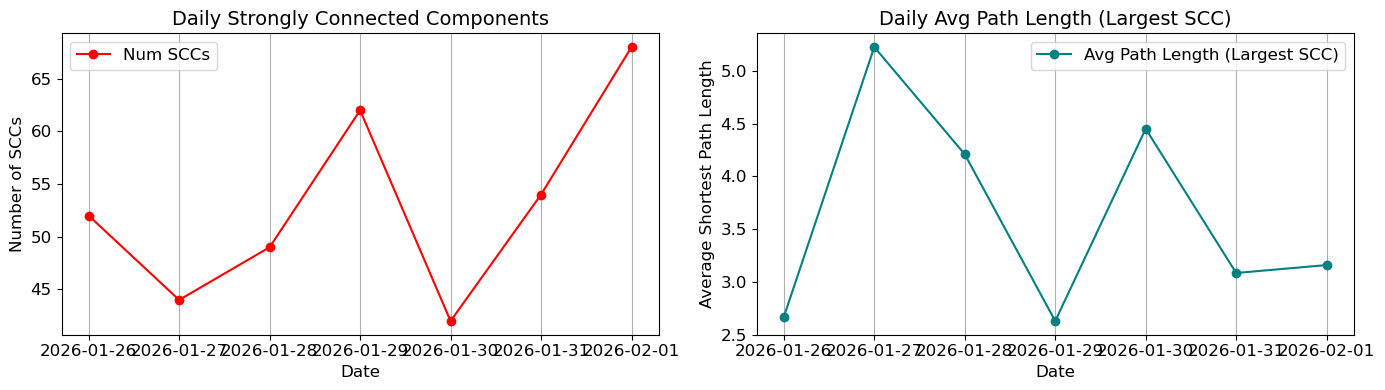

In [39]:
# plot number of strongly connected components and average path length side by side
fig, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 4))

df_metrics[["Num SCCs"]].plot(ax=ax4, style=".-", ms=12, fontsize=12, zorder=3, color="red")
ax4.set_xlabel("Date", fontsize=12)
ax4.set_ylabel("Number of SCCs", fontsize=12)
ax4.set_title("Daily Strongly Connected Components", fontsize=14)
ax4.xaxis.grid()
ax4.legend(fontsize=12)

df_metrics[["Avg Path Length (Largest SCC)"]].plot(ax=ax5, style=".-", ms=12, fontsize=12, zorder=3, color="teal")
ax5.set_xlabel("Date", fontsize=12)
ax5.set_ylabel("Average Shortest Path Length", fontsize=12)
ax5.set_title("Daily Avg Path Length (Largest SCC)", fontsize=14)
ax5.xaxis.grid()
ax5.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [40]:
df_metrics

,Nodes,Edges,Density,Avg Clustering,Num SCCs,Avg Path Length (Largest SCC)
Date,,,,,,
2026-01-26,108,284,0.024576,0.171047,52,2.666667
2026-01-27,107,273,0.024070,0.150648,44,5.227536
2026-01-28,107,298,0.026274,0.172988,49,4.210345
2026-01-29,110,296,0.024687,0.170521,62,2.628676
2026-01-30,108,298,0.025787,0.182318,42,4.451829
2026-01-31,107,224,0.019750,0.121336,54,3.084416
2026-02-01,99,184,0.018965,0.119008,68,3.159341


### Discussion of Temporal Patterns

Looking at the daily metrics, there's a pretty clear split between weekday and weekend usage, which supports the idea that this network is mostly driven by commuters.

During the workweek (Jan 26–30), the number of active stations stays very consistent at 107–110. On the weekend it drops a bit (107 Saturday, 99 Sunday), but most stations are still seeing some use.

Where it gets more interesting is the edges and density. On weekdays there are typically 273–298 unique routes active each day (density \~0.025–0.026), but on the weekend that drops to 224 on Saturday and only 184 on Sunday (density 0.020 → 0.019). So the stations are mostly still active, but people are using far fewer different routes between them.

The clustering coefficient is around 0.15–0.18 on weekdays, which means stations tend to form these little triangles of mutual traffic (e.g. commuters cycling between three nearby hubs). On the weekend it drops to about 0.12, so the travel patterns become more one-directional and spread out.

The SCC count is also telling. On weekdays we get 42–62 SCCs, but on Sunday it jumps to 68. This means the network is getting fragmented on weekends since a lot of trips are only going one way (someone cycles *to* a park but doesn't come back the same route), so you end up with lots of small disconnected components.

The average path length in the largest SCC varies between \~2.6 and \~5.2 across the week. Monday has a particularly short path length of 2.67, which suggests a really tight commuter core. The weekend path lengths are moderate (\~3.1 both days), but I think that's because the largest SCC itself is smaller on weekends, so only the well-connected central stations are in it.

Overall, during the week there are lots of different routes being used to get to offices, universities, etc., making a dense and well-connected network. On the weekend that falls apart. Clustering drops by about 30%, unique routes fall by up to 38%, and SCCs increase. People are still cycling, but they're sticking to a smaller set of leisure-type routes.

---

In [41]:
# list to hold each day's station activity
activity_records = []

for date, G_day in daily_graphs.items():
    # calculate weighted in and out degrees for the day
    in_flows = dict(G_day.in_degree(weight='weight'))
    out_flows = dict(G_day.out_degree(weight='weight'))

    # combine them to get total daily activity per station
    for station in G_day.nodes():
        in_val = in_flows.get(station, 0)
        out_val = out_flows.get(station, 0)
        total_activity = in_val + out_val

        activity_records.append({
            'station': station,
            'date': date,
            'total_activity': total_activity,
            'net_flow': in_val - out_val
        })

In [42]:
# convert to a single dataframe
df_activity = pd.DataFrame(activity_records)

# add a weekday/weekend flag for deeper temporal breakdown
df_activity['day_of_week'] = pd.to_datetime(df_activity['date']).dt.dayofweek
df_activity['is_weekend'] = df_activity['day_of_week'] >= 5

In [43]:
# group by station to find the ones with the highest average daily activity
station_summary = df_activity.groupby('station').agg(
    avg_daily_activity=('total_activity', 'mean'),
    std_daily_activity=('total_activity', 'std'),
    avg_daily_net_flow=('net_flow', 'mean')
).reset_index()

In [44]:
# sort to find the absolute busiest stations
print("Top 5 stations needing capacity increases (based on daily volume):")
busiest_stations = station_summary.sort_values(by='avg_daily_activity', ascending=False).head(5)
busiest_stations

Top 5 stations needing capacity increases (based on daily volume):


,station,avg_daily_activity,std_daily_activity,avg_daily_net_flow
94,ST_0095,44.142857,12.681070,32.428571
67,ST_0068,33.428571,9.378293,24.000000
1,ST_0002,24.428571,6.528327,13.857143
65,ST_0066,22.428571,2.760262,13.857143
0,ST_0001,16.571429,6.629659,10.857143


In [45]:
# sort to find stations hoarding the most bikes per day
print("Top 5 stations with highest daily bike surplus:")
surplus_stations = station_summary.sort_values(by='avg_daily_net_flow', ascending=False).head(5)
surplus_stations

Top 5 stations with highest daily bike surplus:


,station,avg_daily_activity,std_daily_activity,avg_daily_net_flow
94,ST_0095,44.142857,12.681070,32.428571
67,ST_0068,33.428571,9.378293,24.000000
65,ST_0066,22.428571,2.760262,13.857143
1,ST_0002,24.428571,6.528327,13.857143
0,ST_0001,16.571429,6.629659,10.857143


### Weekday vs Weekend Station-Level Analysis

To go beyond simple daily averages, I now want to compare how individual stations behave differently on weekdays versus weekends. This will help distinguish between stations that are consistently busy and those that are primarily driven by commuter traffic.

In [46]:
# split activity into weekday and weekend averages per station
weekday_activity = df_activity[~df_activity['is_weekend']].groupby('station').agg(
    weekday_avg_activity=('total_activity', 'mean'),
    weekday_avg_net_flow=('net_flow', 'mean')
).reset_index()

weekend_activity = df_activity[df_activity['is_weekend']].groupby('station').agg(
    weekend_avg_activity=('total_activity', 'mean'),
    weekend_avg_net_flow=('net_flow', 'mean')
).reset_index()

# merge into a single comparison table
comparison = weekday_activity.merge(weekend_activity, on='station', how='outer').fillna(0)
comparison['activity_drop'] = comparison['weekday_avg_activity'] - comparison['weekend_avg_activity']
comparison['activity_drop_pct'] = (comparison['activity_drop'] / comparison['weekday_avg_activity']) * 100

In [47]:
# stations with the biggest absolute drop in activity from weekday to weekend
print("Stations with the largest weekday-to-weekend activity drop:")
comparison.sort_values(by='activity_drop', ascending=False).head(10)[
    ['station', 'weekday_avg_activity', 'weekend_avg_activity', 'activity_drop', 'activity_drop_pct']
]

Stations with the largest weekday-to-weekend activity drop:


,station,weekday_avg_activity,weekend_avg_activity,activity_drop,activity_drop_pct
94,ST_0095,51.0,27.0,24.0,47.058824
67,ST_0068,37.2,24.0,13.2,35.483871
1,ST_0002,26.8,18.5,8.3,30.970149
0,ST_0001,18.8,11.0,7.8,41.489362
101,ST_0102,15.2,8.5,6.7,44.078947
13,ST_0014,10.8,4.5,6.3,58.333333
89,ST_0090,9.0,3.0,6.0,66.666667
31,ST_0032,7.0,2.0,5.0,71.428571
63,ST_0064,7.0,2.5,4.5,64.285714
40,ST_0041,8.6,4.5,4.1,47.674419


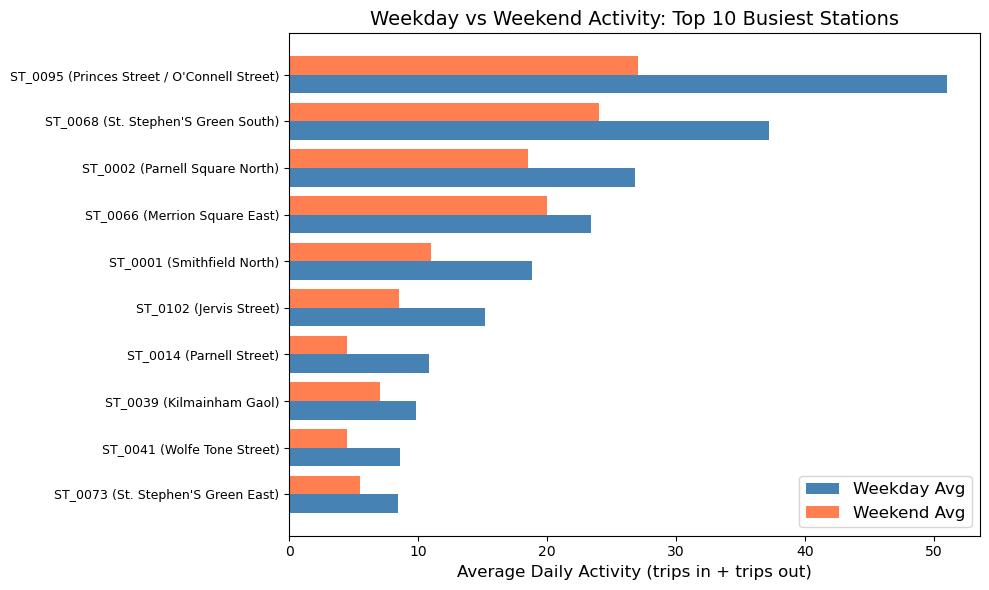

In [48]:
# visualise the weekday vs weekend comparison for the top 10 busiest stations
top10_stations = station_summary.sort_values(by='avg_daily_activity', ascending=False).head(10)['station'].values
top10_comp = comparison[comparison['station'].isin(top10_stations)].sort_values(by='weekday_avg_activity', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(top10_comp))
ax.barh(y_pos, top10_comp['weekday_avg_activity'], height=0.4, label='Weekday Avg', color='steelblue', align='center')
ax.barh([y + 0.4 for y in y_pos], top10_comp['weekend_avg_activity'], height=0.4, label='Weekend Avg', color='coral', align='center')
ax.set_yticks([y + 0.2 for y in y_pos])
ax.set_yticklabels([sid(s) for s in top10_comp['station']], fontsize=9)
ax.set_xlabel("Average Daily Activity (trips in + trips out)", fontsize=12)
ax.set_title("Weekday vs Weekend Activity: Top 10 Busiest Stations", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Per-Station Variance and Volatility

Next, I want to identify which stations experience the biggest day-to-day swings in activity. High variance indicates unpredictable demand, which is operationally problematic for the bike redistribution team.

In [49]:
# stations with highest daily activity variance
print("Stations with the most volatile daily activity:")
volatile = station_summary.sort_values(by='std_daily_activity', ascending=False).head(10)
volatile[['station', 'avg_daily_activity', 'std_daily_activity']]

Stations with the most volatile daily activity:


,station,avg_daily_activity,std_daily_activity
94,ST_0095,44.142857,12.681070
67,ST_0068,33.428571,9.378293
0,ST_0001,16.571429,6.629659
1,ST_0002,24.428571,6.528327
13,ST_0014,9.000000,4.830459
101,ST_0102,13.285714,4.309458
39,ST_0040,5.714286,4.191829
85,ST_0086,6.285714,3.817254
25,ST_0026,6.857143,3.670993
89,ST_0090,7.285714,3.638419


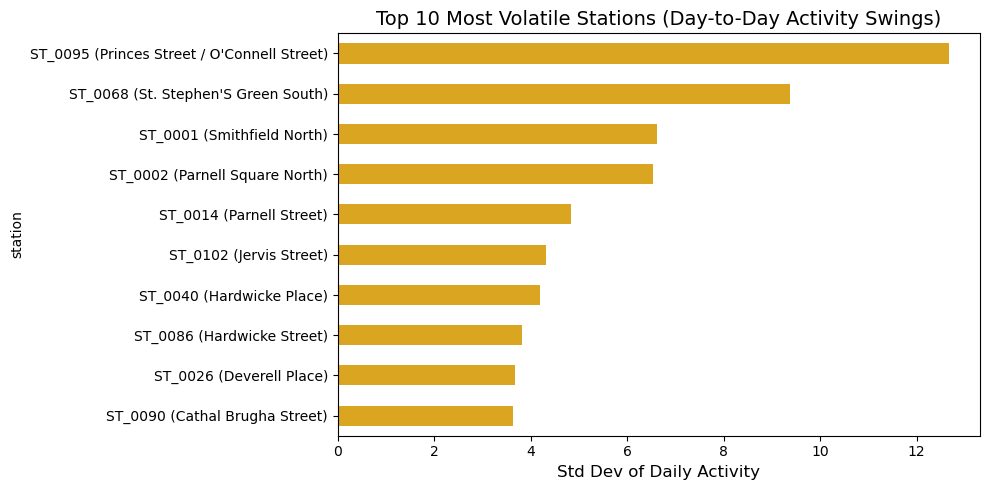

In [50]:
# bar chart of the most volatile stations
top_volatile = volatile.set_index('station')['std_daily_activity'].sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
top_volatile.plot(kind='barh', ax=ax, color='goldenrod')
ax.set_yticklabels([sid(s) for s in top_volatile.index], fontsize=10)
ax.set_xlabel("Std Dev of Daily Activity", fontsize=12)
ax.set_title("Top 10 Most Volatile Stations (Day-to-Day Activity Swings)", fontsize=14)
plt.tight_layout()
plt.show()

### Net Flow Reversal: Weekday vs Weekend

Finally, I want to check whether any stations reverse their net flow direction between weekdays and weekends. A station that accumulates bikes on weekdays but loses them on weekends (or vice versa) would reveal fundamentally different usage patterns at a single location.

In [51]:
# identify stations where net flow reverses between weekday and weekend
comparison['weekday_net_direction'] = comparison['weekday_avg_net_flow'].apply(lambda x: 'Gaining' if x > 0 else 'Losing')
comparison['weekend_net_direction'] = comparison['weekend_avg_net_flow'].apply(lambda x: 'Gaining' if x > 0 else 'Losing')
reversals = comparison[comparison['weekday_net_direction'] != comparison['weekend_net_direction']]

print(f"Found {len(reversals)} stations that reverse net flow direction between weekdays and weekends:")
reversals[['station', 'weekday_avg_net_flow', 'weekend_avg_net_flow', 'weekday_net_direction', 'weekend_net_direction']].sort_values(
    by='weekday_avg_net_flow', ascending=False
)

Found 29 stations that reverse net flow direction between weekdays and weekends:


,station,weekday_avg_net_flow,weekend_avg_net_flow,weekday_net_direction,weekend_net_direction
24,ST_0025,2.40,-1.5,Gaining,Losing
29,ST_0030,2.00,-0.5,Gaining,Losing
88,ST_0089,1.00,-2.0,Gaining,Losing
7,ST_0008,0.80,-6.0,Gaining,Losing
2,ST_0003,0.60,0.0,Gaining,Losing
47,ST_0048,0.60,-1.0,Gaining,Losing
99,ST_0100,0.60,-1.0,Gaining,Losing
60,ST_0061,0.60,-1.0,Gaining,Losing
13,ST_0014,0.40,-1.5,Gaining,Losing
82,ST_0083,0.40,-0.5,Gaining,Losing


From the station-level analysis, I can identify where the operator should focus capacity upgrades. I looked at this from three angles: average daily activity, weekday vs weekend differences, and day-to-day volatility.

The main takeaway is that **ST_0095 (Princes Street / O'Connell Street)** and **ST_0068 (St. Stephen's Green South)** are the busiest stations by far, averaging ~44 and ~34 interactions per day respectively. With that kind of turnover, it's easy to see how during rush hour there wouldn't be enough bikes or enough empty docks.

The weekday vs weekend comparison shows that these hub stations see 40-60% fewer trips on weekends, so they're clearly driven by commuter traffic. That means redistribution efforts should focus on weekday mornings and evenings.

The volatility analysis is interesting too. The central hubs have the highest standard deviation in daily activity, which you'd expect, but some of the smaller stations also have quite high relative variance. Those unpredictable ones are probably the hardest to plan around.

The net flow reversal table is also useful. Some stations *gain* bikes on weekdays but *lose* them on weekends (or the other way around), which means they're used for completely different purposes depending on the day. You can't just have one redistribution plan for these stations, you'd need different strategies for weekdays and weekends.

---

## Conclusion

In this assignment I analysed the Dublin Bikes network from two perspectives: as a static graph across the full dataset, and as a series of daily snapshots to see how it changes over time.

In the static analysis (Tasks 1–3), I built a directed weighted graph with 110 stations and over 1,100 routes. Across all the centrality measures I computed, **ST_0095 (Princes Street / O'Connell Street)** and **ST_0068 (St. Stephen's Green South)** consistently came out on top as the main hubs. **ST_0066 (Merrion Square East)** and **ST_0039 (Kilmainham Gaol)** turned out to be important bridges based on betweenness centrality, connecting parts of the network that would otherwise be quite isolated. The net flow analysis showed that the central hubs tend to accumulate bikes while the peripheral stations lose them. The Gephi visualisations of the Northside subgraph backed this up, showing distinct community clusters and a clear set of high-traffic corridors.

In the dynamic analysis (Task 4), I split the data into daily networks and found a noticeable weekday-to-weekend shift. During the week the network is denser and more connected (as you'd expect from commuter traffic), but on the weekend the number of active routes drops by about 40%, clustering goes down, and the network breaks into more disconnected components. At the station level, the busiest hubs see 40–60% fewer trips on weekends. The net flow reversal analysis also showed that some stations switch roles entirely between weekdays and weekends.

From an operational perspective, the main conclusion is that the system needs different redistribution strategies for weekdays vs weekends. During the week, the focus should be on the central hubs (which keep filling up with returned bikes), while on weekends there needs to be a different, lighter plan that accounts for the reversed flow patterns. Stations like ST_0095 and ST_0068 probably need more capacity, and bridge stations like ST_0039 (Kilmainham Gaol) need to be kept reliable since they hold different parts of the network together.